In [2]:
using Distributions
using MCMCChains
using Plots
using Random
using StatsPlots
using Turing

### Coin Flipping withouth `Turing`

In [5]:
ptrue = 0.5
N = 100
ns = 0:N

0:100

In [6]:
# Random.seed!(9086)
data = rand(Bernoulli(ptrue), N)
data[1:5]

5-element Array{Int64,1}:
 1
 0
 1
 0
 0

In [7]:
betaprior = Beta(1, 1)

Beta{Float64}(α=1.0, β=1.0)

┌ Info: Saved animation to 
│   fn = /Users/dsp/Learning/julia/turing/tutorial/tmp.gif
└ @ Plots /Users/dsp/.julia/packages/Plots/qZHsp/src/animation.jl:98


Plots.AnimatedGif("/Users/dsp/Learning/julia/turing/tutorial/tmp.gif")
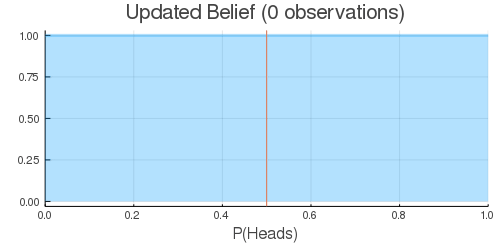

In [8]:
anim = @gif for (i, N) in enumerate(ns) # julia enumeration is 1-based
    nheads = sum(data[1:i - 1])
    ntails = N - nheads
    posterior = Beta(betaprior.α + nheads, betaprior.β + ntails)
    plot(posterior,
         size=(500, 250),
         title="Updated Belief ($N observations)",
         xlabel="P(Heads)",
         legend=nothing,
         xlim=(0, 1),
         fill=0,
         α=0.3,
         w=3)
    vline!([ptrue])
end

### Coin Flipping _with_ `Turing`

In [10]:
@model coinflip(data) = begin
    p ~ Beta(1, 1)
    for n in 1:length(data)
        data[n] ~ Bernoulli(p)
    end
end

(::DynamicPPL.ModelGen{(:data,),var"###coinflip#441",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [11]:
# params for Hamiltonian Monte Carlo sampler
ITERS = 1000
EPS = 0.05
TAU = 10

10

In [13]:
chain = sample(coinflip(data), HMC(EPS, TAU), ITERS, progress=false)

Object of type Chains, with data of type 1000×10×1 Array{Real,3}

Iterations        = 1:1000
Thinning interval = 1
Chains            = 1
Samples per chain = 1000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = p

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean     │ std       │ naive_se   │ mcse        │ ess     │
│     │ Symbol     │ Float64  │ Float64   │ Float64    │ Float64     │ Any     │
├─────┼────────────┼──────────┼───────────┼────────────┼─────────────┼─────────┤
│ 1   │ p          │ 0.569816 │ 0.0438001 │ 0.00138508 │ 0.000530486 │ 1591.65 │

Quantiles

│ Row │ parameters │ 2.5%     │ 25.0%   │ 50.0%    │ 75.0%    │ 97.5%    │
│     │ Symbol     │ Float64  │ Float64 │ Float64  │ Float64  │ Float64  │
├─────┼────────────┼──────────┼─────────┼──────────┼──────────┼──────────┤
│ 1   │ p          │ 0.

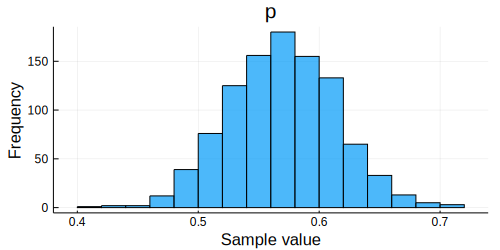

In [14]:
psummary = chain[:p]
plot(psummary, seriestype=:histogram)

In [16]:
n = length(data)
nheads = sum(data)
posterior = Beta(betaprior.α + nheads, betaprior.β + n - nheads)

Beta{Float64}(α=58.0, β=44.0)

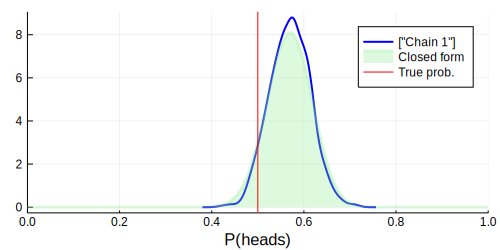

In [21]:
p = plot(
    psummary, seriestype=:density, xlim=(0, 1), legend=:best, w=2, c=:blue
)
plot!(p, 
      range(0, stop=1, length=100), 
      pdf.(Ref(posterior), range(0, stop=1, length=100)),
      label="Closed form",
      xlabel="P(heads)",
      ylabel="",
      title="", 
      xlim=(0, 1),
      fill=0,
      alpha=0.3,
      w=3,
      c=:lightgreen)
vline!(p, [ptrue], label="True prob.", c=:red)